In [ ]:
pip install torch torchvision matplotlib opencv-python


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/Panoramic_Dental_Xray_Dataset"

print("¿Existe la carpeta?", os.path.isdir(DATASET_DIR))
print("Archivos encontrados:", len(os.listdir(DATASET_DIR)))
print("Ejemplo:", os.listdir(DATASET_DIR)[:10])



¿Existe la carpeta? True
Archivos encontrados: 107
Ejemplo: ['30.jpg', '2.jpg', '25.jpg', '28.jpg', '11.jpg', '8.jpg', '17.jpg', '31.jpg', '1.jpg', '16.jpg']


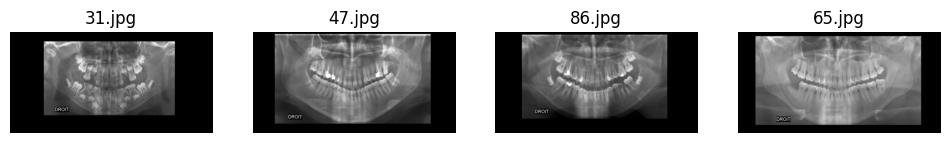

In [ ]:
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image

class DentalXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("L")  # gris
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((256, 512)),  # ajustar tamaño
    transforms.ToTensor()
])

# Dataset y DataLoader
dataset = DentalXrayDataset(DATASET_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Mostrar un batch
images, names = next(iter(dataloader))

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(names[i])
    plt.axis("off")
plt.show()

